Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 200, 64)             │         640,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn (SimpleRNN)               │ (None, 32)                  │           3,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 643,137 (2.45 MB)

 Trainable params: 643,137 (2.45 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/8
500/500 ━━━━━━━━━━━━━━━━━━━━ 33s 58ms/step - accuracy: 0.5117 - loss: 0.7201 - val_accuracy: 0.5867 - val_loss: 0.6761
Epoch 2/8
500/500 ━━━━━━━━━━━━━━━━━━━━ 38s 76ms/step - accuracy: 0.5453 - loss: 0.6871 - val_accuracy: 0.6006 - val_loss: 0.6678
Epoch 3/8
500/500 ━━━━━━━━━━━━━━━━━━━━ 36s 66ms/step - accuracy: 0.5709 - loss: 0.6711 - val_accuracy: 0.6321 - val_loss: 0.6523
Epoch 4/8
500/500 ━━━━━━━━━━━━━━━━━━━━ 40s 65ms/step - accuracy: 0.6161 - loss: 0.6443 - val_accuracy: 0.6661 - val_loss: 0.6192
Epoch 5/8
500/500 ━━━━━━━━━━━━━━━━━━━━ 28s 56ms/step - accuracy: 0.6736 - loss: 0.5934 - val_accuracy: 0.7010 - val_loss: 0.5651
Epoch 6/8
500/500 ━━━━━━━━━━━━━━━━━━━━ 50s 70ms/step - accuracy: 0.7430 - loss: 0.5225 - val_accuracy: 0.7494 - val_loss: 0.5082
Epoch 7/8
500/500 ━━━━━━━━━━━━━━━━━━━━ 45s 77ms/step - accuracy: 0.7721 - loss: 0.4888 - val_accuracy: 0.7663 - val_loss: 0.4922
Epoch 8/8
500/500 ━━━━━━━━━━━━━━━━━━━━ 38s 70ms/step - accuracy: 0.7936 - loss: 0.4603 - val_accu

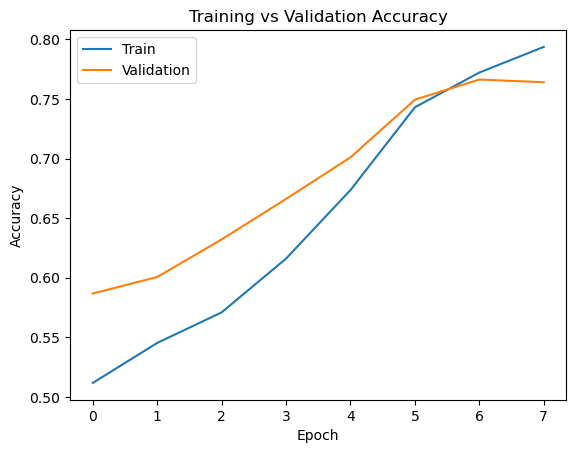

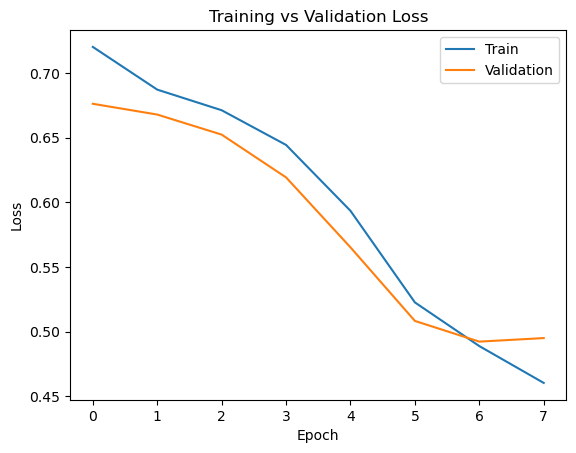

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.7686 - loss: 0.4918
Test Accuracy: 76.85999870300293
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step


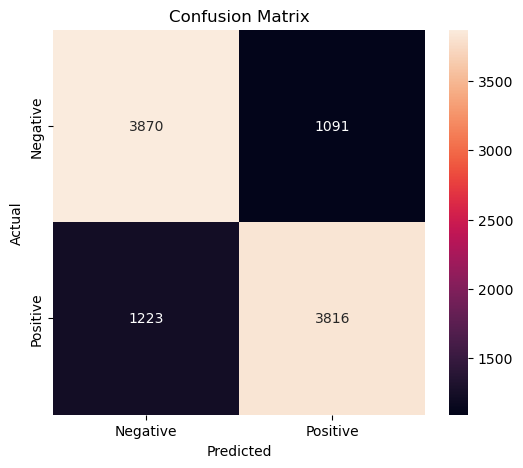


Classification Report:

              precision    recall  f1-score   support

    Negative       0.76      0.78      0.77      4961
    Positive       0.78      0.76      0.77      5039

    accuracy                           0.77     10000
   macro avg       0.77      0.77      0.77     10000
weighted avg       0.77      0.77      0.77     10000



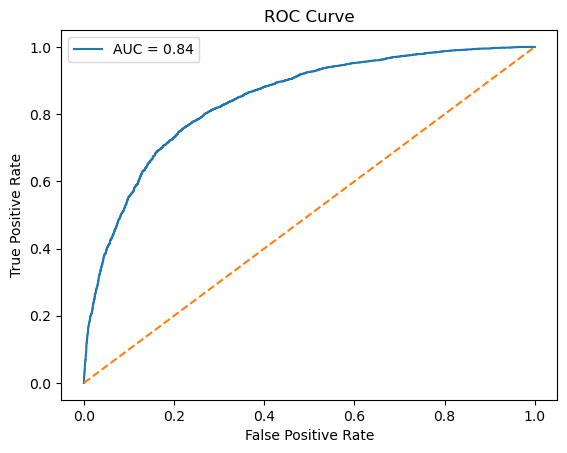

In [1]:
# Balanced RNN for IMDB Sentiment Classification (FINAL VERSION WITH ROC)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


# 1. Load Dataset
data = pd.read_csv(r"C:\Users\Janani\Downloads\archive (1)\IMDB Dataset.csv")

# 2. Preprocessing
data['sentiment'] = data['sentiment'].map({'positive':1, 'negative':0})

X = data['review']
y = data['sentiment']


# 3. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# 4. Tokenization
vocab_size = 10000
tokenizer = Tokenizer(num_words=vocab_size)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)


# 5. Padding
max_length = 200
X_train_pad = pad_sequences(X_train_seq, maxlen=max_length)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_length)


# 6. Build Model (Balanced)
model = Sequential()

model.add(Embedding(vocab_size, 64))
model.add(SimpleRNN(32, dropout=0.2, recurrent_dropout=0.2))
model.add(Dropout(0.4))
model.add(Dense(1, activation='sigmoid'))


# 7. Compile
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.build(input_shape=(None, max_length))
model.summary()


# 8. Early Stopping
early_stop = EarlyStopping(monitor='val_loss',
                           patience=2,
                           restore_best_weights=True)


# 9. Train
history = model.fit(
    X_train_pad,
    y_train,
    epochs=8,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)


# 10. Accuracy Graph
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()


# 11. Loss Graph
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.show()


# 12. Evaluation
test_loss, test_accuracy = model.evaluate(X_test_pad, y_test)

print("Test Accuracy:", test_accuracy * 100)


# 13. Predictions
y_pred_prob = model.predict(X_test_pad)
y_pred = (y_pred_prob > 0.5).astype("int32")


# 14. Confusion Matrix (IMAGE)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Negative','Positive'],
            yticklabels=['Negative','Positive'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# 15. Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))


# 16. ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')  # random line
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()